In [ ]:
import sys
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import tqdm
import joblib
import contextlib
import io
import re
from collections import defaultdict
from scipy import stats

import torch
from dataset.data_classes import PytorchSpectraDataset
from dataset.dataset_builder import SpectralDatasetBuilder

from models.cdiff_lightning import LitCfgDiffusion
from models.cvae_lightning import LitVAE
from models.cbegan_lightning import SpectralCBEGAN
from utils.utils import encode_labels, load_config

from utils.experiments import load_models, generate_batch_spectra, load_colors

from tools.Evaluator_FTIR import Evaluator_FTIR
from tools.Evaluator_Peak_Ratios import Evaluator_Peak_Ratios
from tools.Loss_Metric_Manager import Loss_Metric_Manager

In [2]:
# Load data info, scalers and the categorical encoder
label_encoder = joblib.load("../pretrained_models/scalers/label_encoder.pkl")
minmax_scaler = joblib.load("../pretrained_models/scalers/minmax_scaler.pkl")
categorical_conditions = joblib.load("../pretrained_models/scalers/categorical_conditions.pkl")
continuous_conditions = joblib.load("../pretrained_models/scalers/continuous_conditions.pkl")
standard_scaler = joblib.load("../pretrained_models/scalers/std_scaler.pkl")

c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = load_models()

cfg = load_config('../config.yaml')
continous_conditions = cfg["condition_labels"]["continuous"]
categorical_conditions = cfg["condition_labels"]["categorical"]
conditions = categorical_conditions + continous_conditions

conditions_gan_vae = ['age', 'sex', 'bmi']

In [4]:
dataset_builder = SpectralDatasetBuilder(data_path='../data/in-silico-gen-data.parquet', data_split={"train": 0.8, "test": 0.2}, config_path='../config.yaml')
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
column_names = dataset.df_test_scaled.iloc[:,:519].columns.values.astype(float)

y_real = dataset.df_test_normalized[conditions]
bmi_age = y_real[['bmi', 'age']]
bmi_age = dataset_builder.minmax_scaler.inverse_transform(bmi_age).T
bmi = bmi_age[0]
age = bmi_age[1]
sex = y_real['sex'].map({0: 'male', 1:'female'}).values

y_df = pd.DataFrame({
    "sex": sex,
    "bmi": bmi,
    "age": age
})

In [5]:
'''
synthetic_datasets = {}

for model_name, model in models.items():
    print(f'now generating {model_name}')
    if model_name == 'CVAE':
        latent_dim = 100
    elif model_name == 'CBEGAN':
        latent_dim = 64
    else:
        latent_dim = 128
        
    X = generate_batch_spectra(model, y_real, column_names, device=device)
    X = pd.DataFrame(X, columns=column_names)
    X[conditions] = y_df
    X['test_set'] = dataset.df_test_normalized['test_set'].values
    X.to_parquet(f'../data/{model_name}_generated.parquet')
    
    synthetic_datasets[model_name] = X
'''

GAN_FILE = "../data/CBEGAN_generated.parquet"
VAE_FILE = "../data/CVAE_generated.parquet"
DIFF_FILE = "../data/CDIFF_generated.parquet"

df_vae = pd.read_parquet(VAE_FILE)
df_gan = pd.read_parquet(GAN_FILE)
df_diff = pd.read_parquet(DIFF_FILE)

vae_data = df_vae.iloc[:,:519].values
gan_data = df_gan.iloc[:,:519].values
diff_data = df_diff.iloc[:,:519].values
real_data = dataset.df_test_scaled.iloc[:,:519].values

now generating CVAE


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\pandas\io\parquet.py:190: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


now generating CBEGAN


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\pandas\io\parquet.py:190: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


now generating CDIFF


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\pandas\io\parquet.py:190: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = self.api.Table.from_pandas(df, **from_pandas_kwargs)


In [6]:
labels = df_vae[["age", "sex", "bmi", "test_set"]]
split_index = df_vae.test_set.values

labels['sex'] = labels['sex'].map({'male': 0, 'female':1})

labels.loc[labels.age <= 52, "age"] = 0
labels.loc[labels.bmi <= 27, "bmi"] = 0

labels.loc[labels.age > 52, "age"] = 1
labels.loc[labels.bmi > 27, "bmi"] = 1

C:\Users\Kerschbaumer\AppData\Local\Temp\ipykernel_7672\1975313316.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels['sex'] = labels['sex'].map({'male': 0, 'female':1})


In [7]:
from collections import OrderedDict

spectra_map = OrderedDict({
    "CVAE": vae_data,
    "CBEGAN": gan_data,
    "CDIFF": diff_data,
    "real": real_data})

label_map = OrderedDict({
    "CVAE": labels.values,
    "CBEGAN": labels.values,
    "CDIFF": labels.values,
    "real": labels.values})

split_index_map = OrderedDict({
    "CVAE": split_index,
    "CBEGAN": split_index,
    "CDIFF": split_index,
    "real": split_index})

colors = load_colors()

label_names = ["age", "sex", "bmi", "test_set"]

vec = column_names

scaler = dataset.standard_scaler

In [8]:
def filter_tuples(input_list, exclude_string):
    return [tup for tup in input_list if exclude_string in tup]

from itertools import combinations, product

condition_prod = list(product(['CDIFF', 'CBEGAN', 'CVAE', 'real'], repeat=2))
condition_comb = list(combinations(['CDIFF', 'CBEGAN', 'CVAE', 'real'], r=2))

condition_comb = filter_tuples(condition_comb, 'real')
condition_prod = filter_tuples(condition_prod, 'real')

condition_roc_groups = [[('real', 'real'),
                        ('real', 'CBEGAN'),
                        ('real', 'CVAE'),
                        ('real', 'CDIFF')],
                        
                        [('real', 'real'),
                        ('CBEGAN', 'real'),
                        ('CVAE', 'real'),
                        ('CDIFF', 'real')]]

In [9]:
labels

,age,sex,bmi,test_set
0,0.0,0,0.0,3
1,0.0,1,1.0,5
2,1.0,1,0.0,3
3,1.0,0,1.0,6
4,0.0,1,0.0,4
...,...,...,...,...
5057,1.0,0,1.0,2
5058,1.0,1,0.0,1
5059,0.0,0,1.0,3
5060,0.0,0,1.0,1


#################################
------------ SPECTRA ------------
#################################
All data in './Spectra' has been deleted. It will be replaced by the plots below.


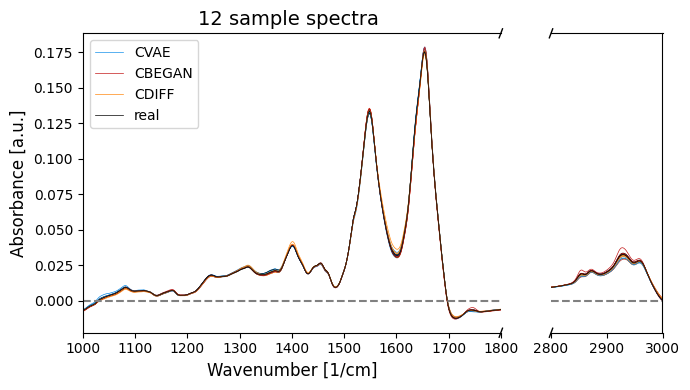

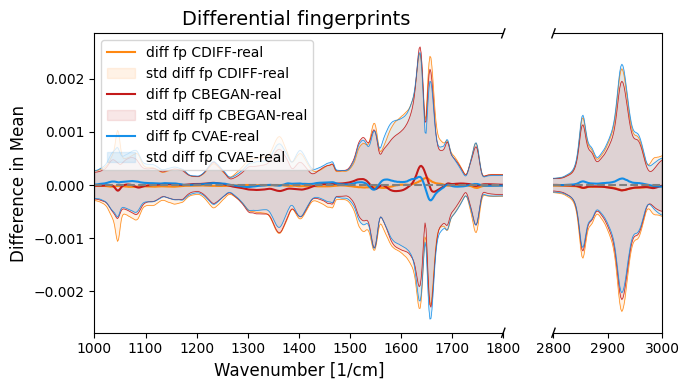

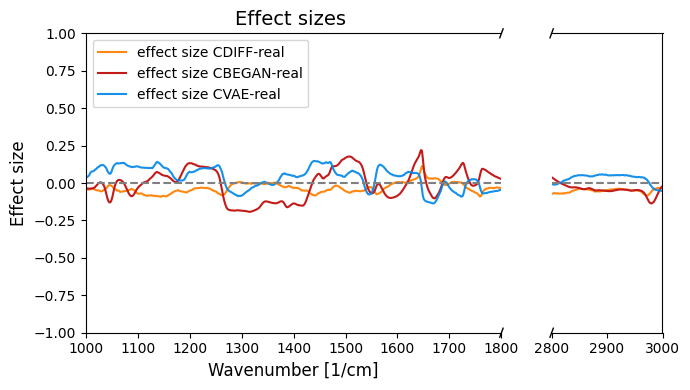

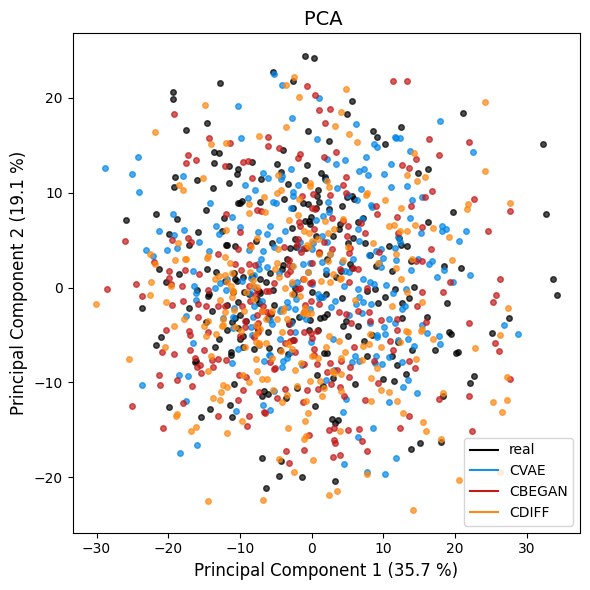

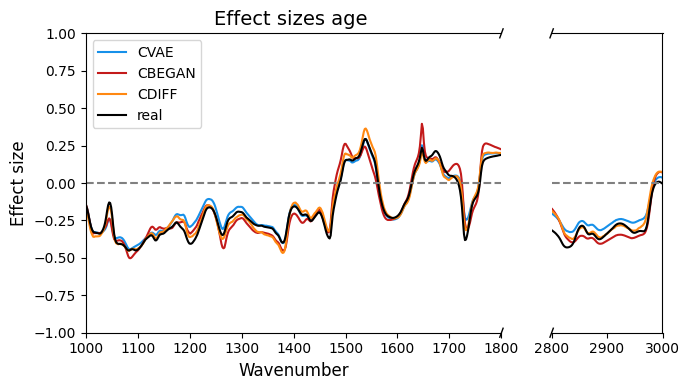

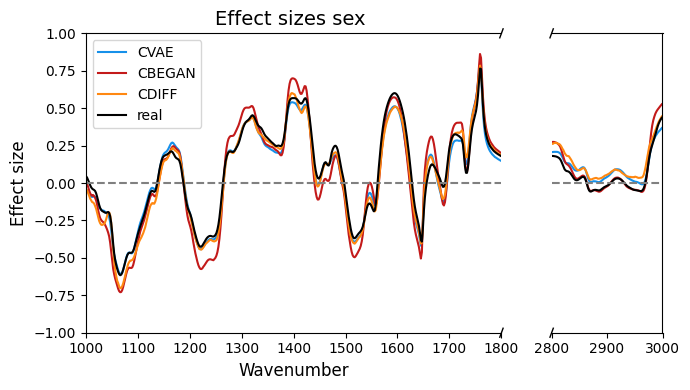

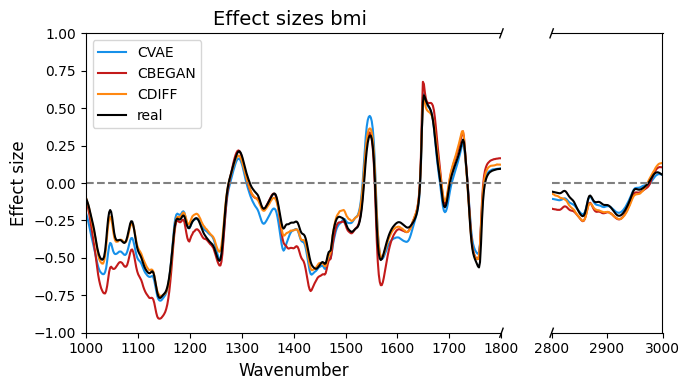

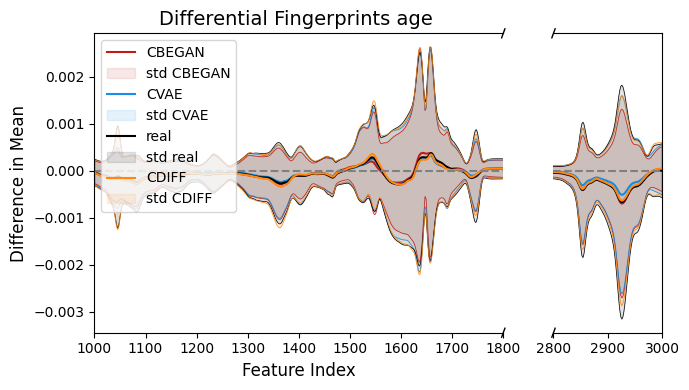

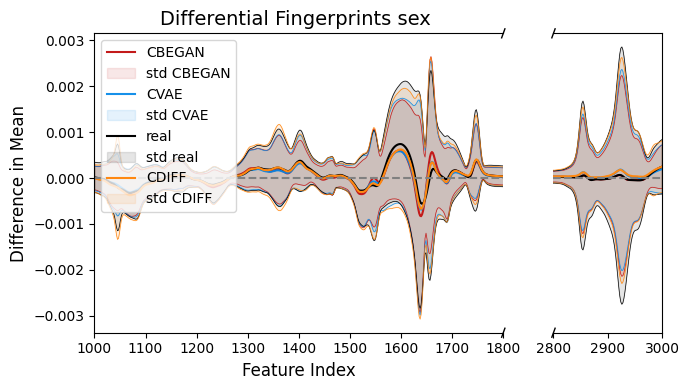

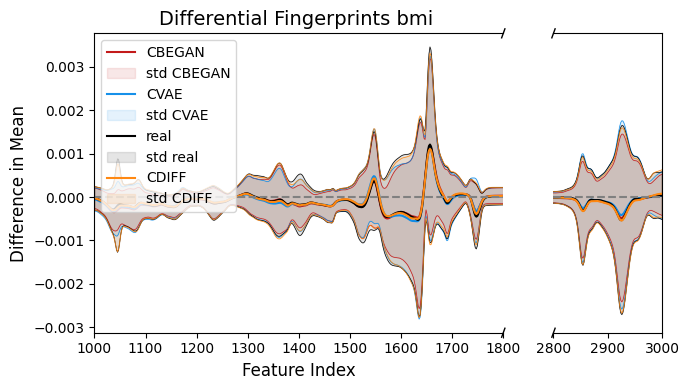

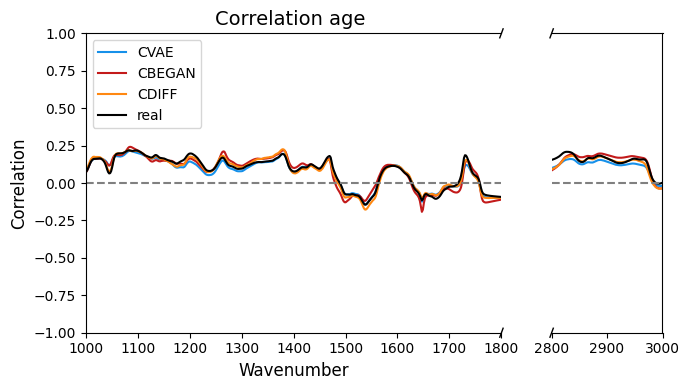

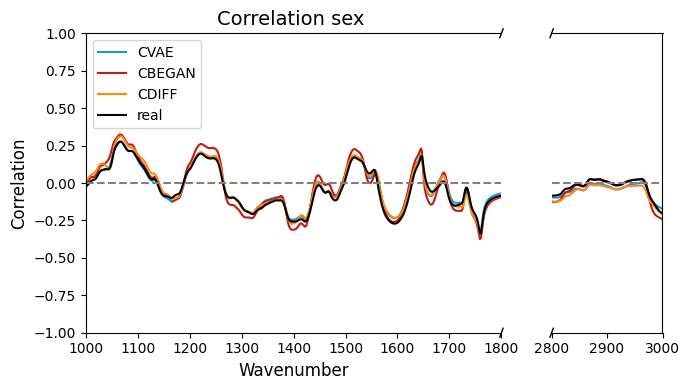

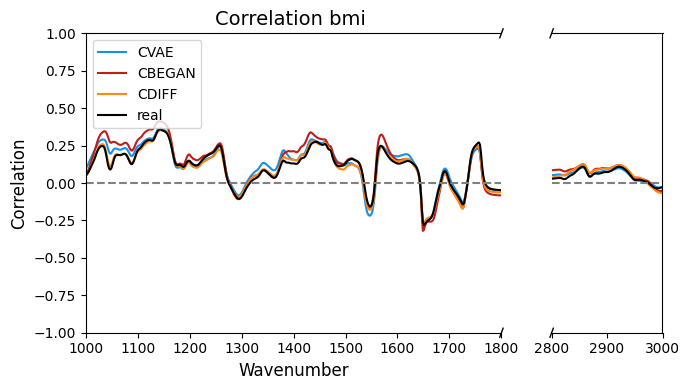

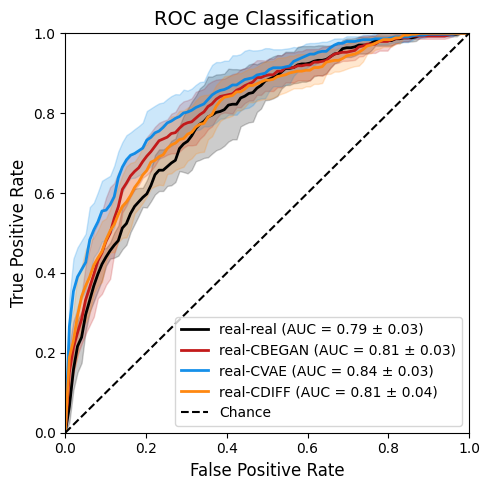

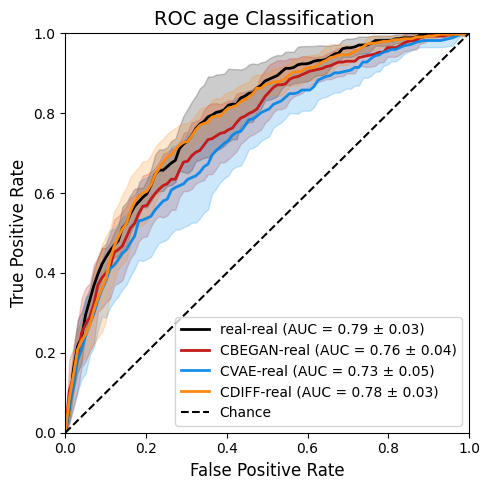

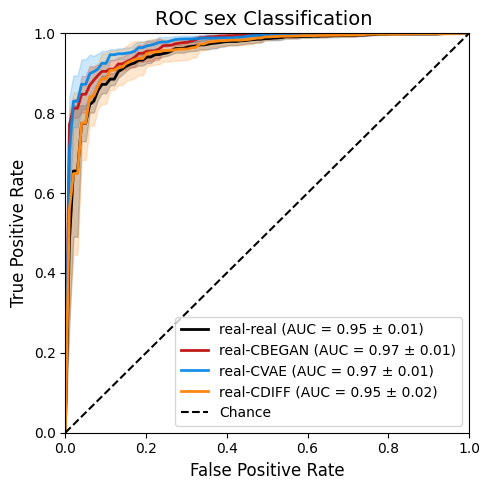

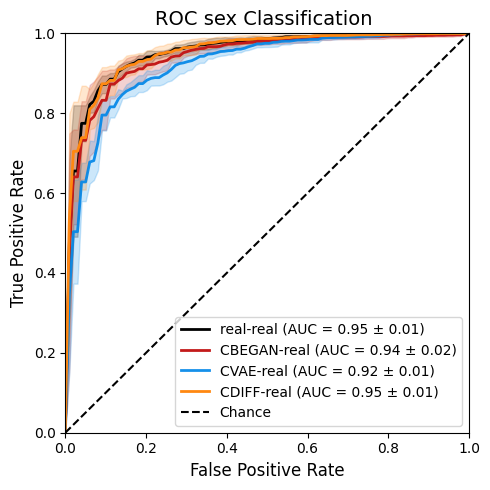

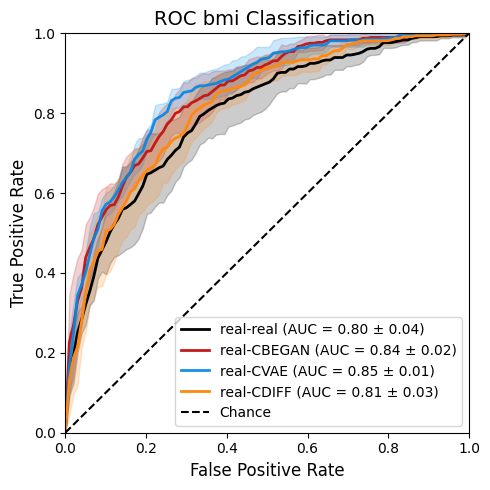

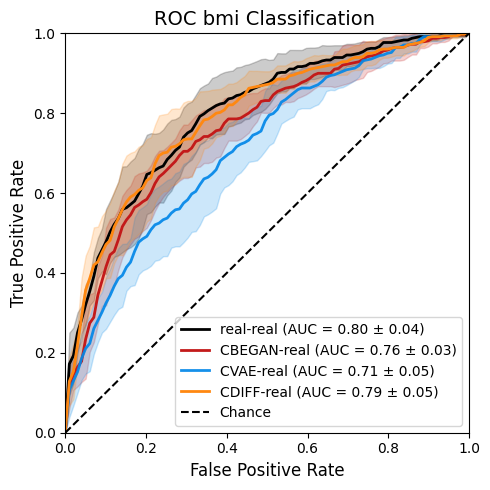

#################################
---------- PEAK RATIOS ----------
#################################
All data in './Peak Ratios' has been deleted. It will be replaced by the plots below.


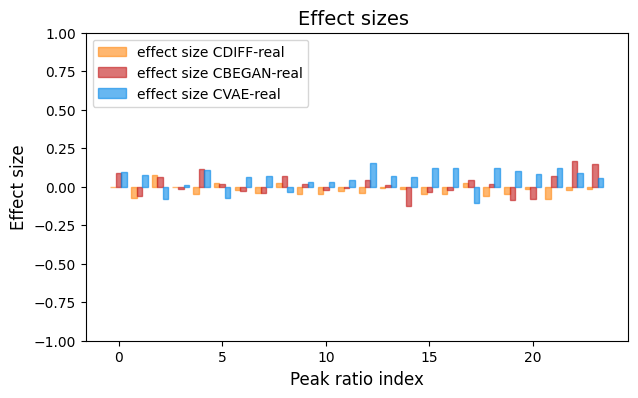

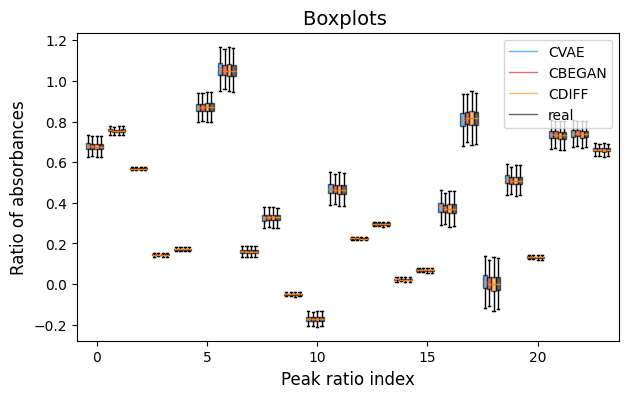

In [13]:
print('#################################')
print('------------ SPECTRA ------------')
print('#################################')

lmm = Loss_Metric_Manager()

evt = Evaluator_FTIR(spectra_map, scaler=standard_scaler, vec=vec, loss_metric_manager=lmm)
evt.figure_settings(directory=f'./Spectra', colors=colors, combination_hierarchy=['CVAE', 'CBEGAN', 'CDIFF', 'real'], skip_directory_check=True)
evt.add_conditions(label_names=label_names, label_map=label_map)

evt.dist.add_sample_spectra(n_spectra=3)
evt.dist.add_differential_fingerprint(stype_combinations=condition_comb)
evt.dist.add_effect_size(stype_combinations=condition_comb)
evt.dist.plot()

evt.dist.add_pca()
evt.dist.plot_pca(n=256, outlier_threshold=2.5)

evt.condition.add_effect_size()
evt.condition.plot_effect_size()

evt.condition.add_differential_fingerprint(stype_combinations=condition_comb)
evt.condition.plot_differential_fingerprint()

evt.condition.add_correlation(convention='pearson')
evt.condition.plot_correlation()

evt.condition.add_roc_svc(split_index_map=split_index_map, stype_products=condition_prod)
evt.condition.plot_roc(group_by=condition_roc_groups)


print('#################################')
print('---------- PEAK RATIOS ----------')
print('#################################')

lmm_pr = Loss_Metric_Manager()

evt_pr = Evaluator_Peak_Ratios(spectra_map, scaler=scaler, vec=vec, loss_metric_manager=lmm_pr)
evt_pr.figure_settings( directory=f'./Peak Ratios', colors=colors, combination_hierarchy=['CVAE', 'CBEGAN', 'CDIFF', 'real'], skip_directory_check=True)
evt_pr.add_conditions(label_names=label_names, label_map=label_map)

evt_pr.dist.add_effect_size(stype_combinations=condition_comb)
evt_pr.dist.add_box_plots()
evt_pr.dist.plot()

# AUC significance

In [16]:
evt.condition.all_aucs

{"('CDIFF', 'real')-age-SVC1": np.float64(0.7804494382022472),
 "('CDIFF', 'real')-age-SVC2": np.float64(0.7717829457364341),
 "('CDIFF', 'real')-age-SVC3": np.float64(0.7524774118332848),
 "('CDIFF', 'real')-age-SVC4": np.float64(0.7601923957856161),
 "('CDIFF', 'real')-age-SVC5": np.float64(0.8078821206993795),
 "('CDIFF', 'real')-age-SVC6": np.float64(0.8277970708138306),
 "('CDIFF', 'real')-sex-SVC1": np.float64(0.9668904958677685),
 "('CDIFF', 'real')-sex-SVC2": np.float64(0.9594495220086143),
 "('CDIFF', 'real')-sex-SVC3": np.float64(0.969050051072523),
 "('CDIFF', 'real')-sex-SVC4": np.float64(0.9365254951538138),
 "('CDIFF', 'real')-sex-SVC5": np.float64(0.9512844611528822),
 "('CDIFF', 'real')-sex-SVC6": np.float64(0.9391528925619835),
 "('CDIFF', 'real')-bmi-SVC1": np.float64(0.7520309843189117),
 "('CDIFF', 'real')-bmi-SVC2": np.float64(0.8725362789690273),
 "('CDIFF', 'real')-bmi-SVC3": np.float64(0.760229132569558),
 "('CDIFF', 'real')-bmi-SVC4": np.float64(0.7854430379746

In [ ]:
results = evt.condition.all_aucs

REAL_MODEL = "real"
SVCS = [f"SVC{i}" for i in range(1, 7)]
 
def parse_key(k):
    # key form: "('CDIFF', 'real')-age-SVC1"
    m = re.match(r"^\((.*?)\)-(.+)-(SVC\d+)$", k)
    tup, covariate, svc = m.group(1), m.group(2), m.group(3)
    model = tup.split(",")[0].strip().strip("'\"")  # first tuple element
    return model, covariate, svc
 
# index: (model, covariate, svc) -> auc
auc = {}
covariates = set()
models = set()
for k, v in results.items():
    model, cov, svc = parse_key(k)
    auc[(model, cov, svc)] = float(v)
    covariates.add(cov)
    models.add(model)
 
gen_models = sorted(m for m in models if m != REAL_MODEL)
covariates = sorted(covariates)
 
rows = []
for model in gen_models:
    for cov in covariates:
        diffs = []
        for svc in SVCS:
            g = auc.get((model, cov, svc))
            r = auc.get((REAL_MODEL, cov, svc))
            if g is None or r is None:
                continue
            diffs.append(g - r)            # generated - real
        diffs = np.array(diffs, dtype=float)
        n = len(diffs)
        mean = diffs.mean()
        sd = diffs.std(ddof=1)
        se = sd / np.sqrt(n)
        t_stat, p_val = stats.ttest_1samp(diffs, 0.0)
        tcrit = stats.t.ppf(0.975, df=n - 1)
        ci_low, ci_high = mean - tcrit * se, mean + tcrit * se
        rows.append((model, cov, n, mean, sd, se, ci_low, ci_high, t_stat, p_val))

 
def fmt_p(p):
    return "$<0.001$" if p < 0.001 else f"{p:.3f}"
 
df = pd.DataFrame(
    [
        {
            "Model": model,
            "Covariate": cov,
            "Mean": f"{mean:.3f}",
            "SD": f"{sd:.3f}",
            "SE": f"{se:.3f}",
            "95\\% CI": f"[{lo:.3f}, {hi:.3f}]",
            "$p$": fmt_p(p),
        }
        for (model, cov, n, mean, sd, se, lo, hi, t, p) in rows
    ]
)
 
latex = df.to_latex(
    index=False,
    escape=False,
    column_format="llrrrrr",
    caption=(
        "Mean AUC difference (generated $-$ real) across the six SVCs, "
        "with standard deviation, standard error, 95\\% confidence interval, "
        "and paired $t$-test $p$-value."
    ),
    label="tab:auc_diff",
    position="ht",
)
print(latex)


\begin{table}[ht]
\caption{Mean AUC difference (generated $-$ real) across the six SVCs, with standard deviation, standard error, 95\% confidence interval, and paired $t$-test $p$-value.}
\label{tab:auc_diff}
\begin{tabular}{llrrrrr}
\toprule
Model & Covariate & Mean & SD & SE & 95\% CI & $p$ \\
\midrule
CBEGAN & age & -0.030 & 0.032 & 0.013 & [-0.064, 0.004] & 0.076 \\
CBEGAN & bmi & -0.037 & 0.028 & 0.012 & [-0.067, -0.007] & 0.024 \\
CBEGAN & sex & -0.011 & 0.013 & 0.005 & [-0.024, 0.002] & 0.086 \\
CDIFF & age & -0.006 & 0.018 & 0.007 & [-0.025, 0.012] & 0.429 \\
CDIFF & bmi & -0.007 & 0.016 & 0.007 & [-0.024, 0.009] & 0.315 \\
CDIFF & sex & 0.001 & 0.005 & 0.002 & [-0.005, 0.007] & 0.743 \\
CVAE & age & -0.055 & 0.035 & 0.014 & [-0.091, -0.018] & 0.012 \\
CVAE & bmi & -0.084 & 0.034 & 0.014 & [-0.119, -0.049] & 0.002 \\
CVAE & sex & -0.031 & 0.012 & 0.005 & [-0.043, -0.019] & 0.001 \\
\bottomrule
\end{tabular}
\end{table}



# sample spectra inset

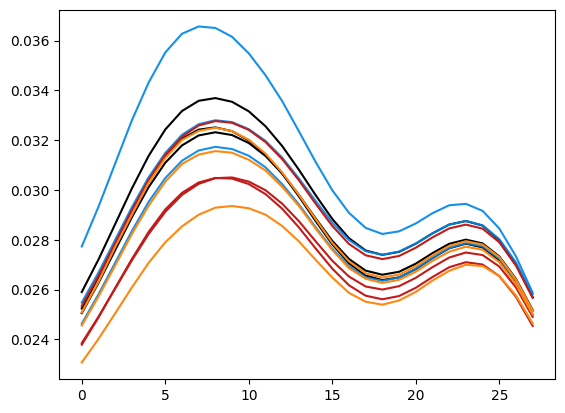

In [36]:
plt.plot(standard_scaler.inverse_transform(real_data[:3])[:, 474:502].T, color=colors['real'])
plt.plot(standard_scaler.inverse_transform(vae_data[:3])[:, 474:502].T, color=colors['CVAE'])
plt.plot(standard_scaler.inverse_transform(gan_data[:3])[:, 474:502].T, color=colors['CBEGAN'])
plt.plot(standard_scaler.inverse_transform(diff_data[:3])[:, 474:502].T, color=colors['CDIFF'])
plt.savefig('sample_spectra_inset.pdf')
plt.show()

## age-, bmi-threshold sensititvity

In [41]:
age_thresholds = [46, 49, 52, 55, 58, 61]
bmi_thresholds = [23, 25, 27, 29, 31, 33]

In [42]:
def make_labels(df_source, age_thr, bmi_thr):
    """
    Return a labels DataFrame with age and bmi binarised at the given
    thresholds.  sex and test_set are taken verbatim from df_source.
    """
    lbl = df_source[["age", "sex", "bmi", "test_set"]].copy()
    lbl["sex"] = lbl["sex"].map({"male": 0, "female": 1})
 
    lbl["age"] = (lbl["age"] > age_thr).astype(int)
    lbl["bmi"] = (lbl["bmi"] > bmi_thr).astype(int)
 
    return lbl

In [ ]:
auc_rows = []
 
for age_thr, bmi_thr in zip(age_thresholds, bmi_thresholds):
 
    print(f"\n{'='*60}")
    print(f"  Age threshold: {age_thr}   |   BMI threshold: {bmi_thr}")
    print(f"{'='*60}")
 
    # -- Binarise labels for this threshold combination ----------------------
    lbl = make_labels(df_vae, age_thr, bmi_thr)
    lbl_values = lbl.values
    split_index = df_vae["test_set"].values
 
    label_map_thr = OrderedDict({
        "CVAE":   lbl_values,
        "CBEGAN": lbl_values,
        "CDIFF":  lbl_values,
        "real":   lbl_values,
    })
 
    split_index_map_thr = OrderedDict({
        "CVAE":   split_index,
        "CBEGAN": split_index,
        "CDIFF":  split_index,
        "real":   split_index,
    })
 
    # -- Output directory name -----------------------------------------------
    out_dir = f"./Sensitivity/age{age_thr}_bmi{bmi_thr}"
 
    # -- Build evaluator -----------------------------------------------------
    lmm_thr = Loss_Metric_Manager()
 
    evt_thr = Evaluator_FTIR(
        spectra_map,
        scaler=standard_scaler,
        vec=vec,
        loss_metric_manager=lmm_thr,
    )
    evt_thr.figure_settings(
        directory=out_dir,
        colors=colors,
        combination_hierarchy=["CVAE", "CBEGAN", "CDIFF", "real"],
        skip_directory_check=True,
    )
    evt_thr.add_conditions(
        label_names=label_names,
        label_map=label_map_thr,
    )
 
    # -- ROC / AUC (no plot) -------------------------------------------------
    evt_thr.condition.add_roc_svc(
        split_index_map=split_index_map_thr,
        stype_products=condition_prod,
    )
 
    # -- Extract AUCs from roc_results ---------------------------------------
    # roc_results[stype_tuple][label] = [avg_fpr, avg_tpr, std_tpr, avg_auc, std_auc]
    for stype, label_dict in evt_thr.condition.roc_results.items():
        for label, roc_data in label_dict.items():
            auc_rows.append({
                "age_threshold": age_thr,
                "bmi_threshold": bmi_thr,
                "train_stype":   stype[0],
                "test_stype":    stype[1],
                "label":         label,
                "avg_auc":       roc_data[3],
                "std_auc":       roc_data[4],
            })



  Age threshold: 46   |   BMI threshold: 23
All data in './Sensitivity/age46_bmi23' has been deleted. It will be replaced by the plots below.

  Age threshold: 49   |   BMI threshold: 25
All data in './Sensitivity/age49_bmi25' has been deleted. It will be replaced by the plots below.

  Age threshold: 52   |   BMI threshold: 27
All data in './Sensitivity/age52_bmi27' has been deleted. It will be replaced by the plots below.

  Age threshold: 55   |   BMI threshold: 29
All data in './Sensitivity/age55_bmi29' has been deleted. It will be replaced by the plots below.

  Age threshold: 58   |   BMI threshold: 31
All data in './Sensitivity/age58_bmi31' has been deleted. It will be replaced by the plots below.

  Age threshold: 61   |   BMI threshold: 33


In [ ]:
auc_df = pd.DataFrame(auc_rows)

# Keep only rows where test data is real and exclude sex label
auc_filtered = auc_df[(auc_df["test_stype"] == "real") & (auc_df["label"] != "sex")]

# Split by label and pivot — test_stype is constant (real) so drop it as a column
for label in ["age", "bmi"]:
    df_label = auc_filtered[auc_filtered["label"] == label]
    index_col = "age_threshold" if label == "age" else "bmi_threshold"
    avg = df_label.pivot_table(
        index=index_col,
        columns="train_stype",
        values="avg_auc",
    )
    std = df_label.pivot_table(
        index=index_col,
        columns="train_stype",
        values="std_auc",
    )
    col_order = ["real", "CVAE", "CBEGAN", "CDIFF"]
    avg = avg[col_order]
    std = std[col_order]
    avg.columns.name = None
    std.columns.name = None
    
    # Combine into a single table with MultiIndex columns (model, metric)
    pivot = pd.concat({"avg_auc": avg, "std_auc": std}, axis=1).swaplevel(axis=1)[col_order]
    print(f"\nAUC — {label.upper()}\n")
    display(pivot)

    if label == "age":
        pivot_age = pivot
    else:
        pivot_bmi = pivot


AUC — AGE



real                CVAE              CBEGAN            \
                avg_auc   std_auc   avg_auc   std_auc   avg_auc   std_auc   
age_threshold                                                               
46             0.730204  0.040423  0.688009  0.025741  0.714623  0.029509   
49             0.749459  0.043041  0.707556  0.028341  0.733014  0.035892   
52             0.789657  0.031983  0.736586  0.052108  0.761456  0.037421   
55             0.780092  0.020795  0.719062  0.037130  0.770163  0.036478   
58             0.773150  0.036695  0.745239  0.038014  0.774723  0.049243   
61             0.759956  0.058724  0.759501  0.064518  0.765772  0.070336   

                  CDIFF            
                avg_auc   std_auc  
age_threshold                      
46             0.676663  0.023909  
49             0.756884  0.026193  
52             0.794795  0.030175  
55             0.783390  0.022773  
58             0.796871  0.033150  
61             0.779088  0.043417


AUC — BMI



real                CVAE              CBEGAN            \
                avg_auc   std_auc   avg_auc   std_auc   avg_auc   std_auc   
bmi_threshold                                                               
23             0.779270  0.045126  0.731559  0.054455  0.758706  0.037970   
25             0.793464  0.031044  0.714590  0.032305  0.736945  0.033736   
27             0.798260  0.041178  0.711433  0.041993  0.752836  0.043518   
29             0.788817  0.042824  0.704785  0.039298  0.794742  0.022033   
31             0.780975  0.040006  0.718365  0.056417  0.788555  0.028411   
33             0.769355  0.064354  0.738760  0.064592  0.792628  0.022892   

                  CDIFF            
                avg_auc   std_auc  
bmi_threshold                      
23             0.779667  0.022727  
25             0.776698  0.015956  
27             0.792798  0.033536  
29             0.786931  0.042139  
31             0.784303  0.038873  
33             0.767237  0.050829

In [47]:
for label, pivot in [("age", pivot_age), ("bmi", pivot_bmi)]:
    col_order = ["real", "CVAE", "CBEGAN", "CDIFF"]
    index_col = "age_threshold" if label == "age" else "bmi_threshold"

    avg = pivot.xs("avg_auc", axis=1, level=1)
    std = pivot.xs("std_auc", axis=1, level=1)

    # Build cell strings: "avg ± std"
    cell_df = pd.DataFrame(index=pivot.index, columns=col_order)
    for col in col_order:
        cell_df[col] = avg[col].map(lambda x: f"{x:.3f}") + r" $\pm$ " + std[col].map(lambda x: f"{x:.3f}")

    # Render LaTeX
    latex = cell_df.to_latex(
        escape=False,
        caption=f"AUC $\\pm$ std — {label.upper()} (test set: real)",
        label=f"tab:auc_{label}",
        column_format="c" * (len(col_order) + 1),
        index_names=True,
    )
    print(latex)

\begin{table}
\caption{AUC $\pm$ std — AGE (test set: real)}
\label{tab:auc_age}
\begin{tabular}{ccccc}
\toprule
 & real & CVAE & CBEGAN & CDIFF \\
age_threshold &  &  &  &  \\
\midrule
46 & 0.730 $\pm$ 0.040 & 0.688 $\pm$ 0.026 & 0.715 $\pm$ 0.030 & 0.677 $\pm$ 0.024 \\
49 & 0.749 $\pm$ 0.043 & 0.708 $\pm$ 0.028 & 0.733 $\pm$ 0.036 & 0.757 $\pm$ 0.026 \\
52 & 0.790 $\pm$ 0.032 & 0.737 $\pm$ 0.052 & 0.761 $\pm$ 0.037 & 0.795 $\pm$ 0.030 \\
55 & 0.780 $\pm$ 0.021 & 0.719 $\pm$ 0.037 & 0.770 $\pm$ 0.036 & 0.783 $\pm$ 0.023 \\
58 & 0.773 $\pm$ 0.037 & 0.745 $\pm$ 0.038 & 0.775 $\pm$ 0.049 & 0.797 $\pm$ 0.033 \\
61 & 0.760 $\pm$ 0.059 & 0.760 $\pm$ 0.065 & 0.766 $\pm$ 0.070 & 0.779 $\pm$ 0.043 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{AUC $\pm$ std — BMI (test set: real)}
\label{tab:auc_bmi}
\begin{tabular}{ccccc}
\toprule
 & real & CVAE & CBEGAN & CDIFF \\
bmi_threshold &  &  &  &  \\
\midrule
23 & 0.779 $\pm$ 0.045 & 0.732 $\pm$ 0.054 & 0.759 $\pm$ 0.038 & 0.780 $\

In [43]:
effect_size_results = {}
for age_thr, bmi_thr in zip(age_thresholds, bmi_thresholds):

    evt_thr.condition.add_effect_size()
    effect_size_results[(age_thr, bmi_thr)] = {
        stype: dict(evt_thr.condition.effect_size[stype])
        for stype in evt_thr.condition.effect_size
    }

/tmp/ipykernel_20977/2030598061.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


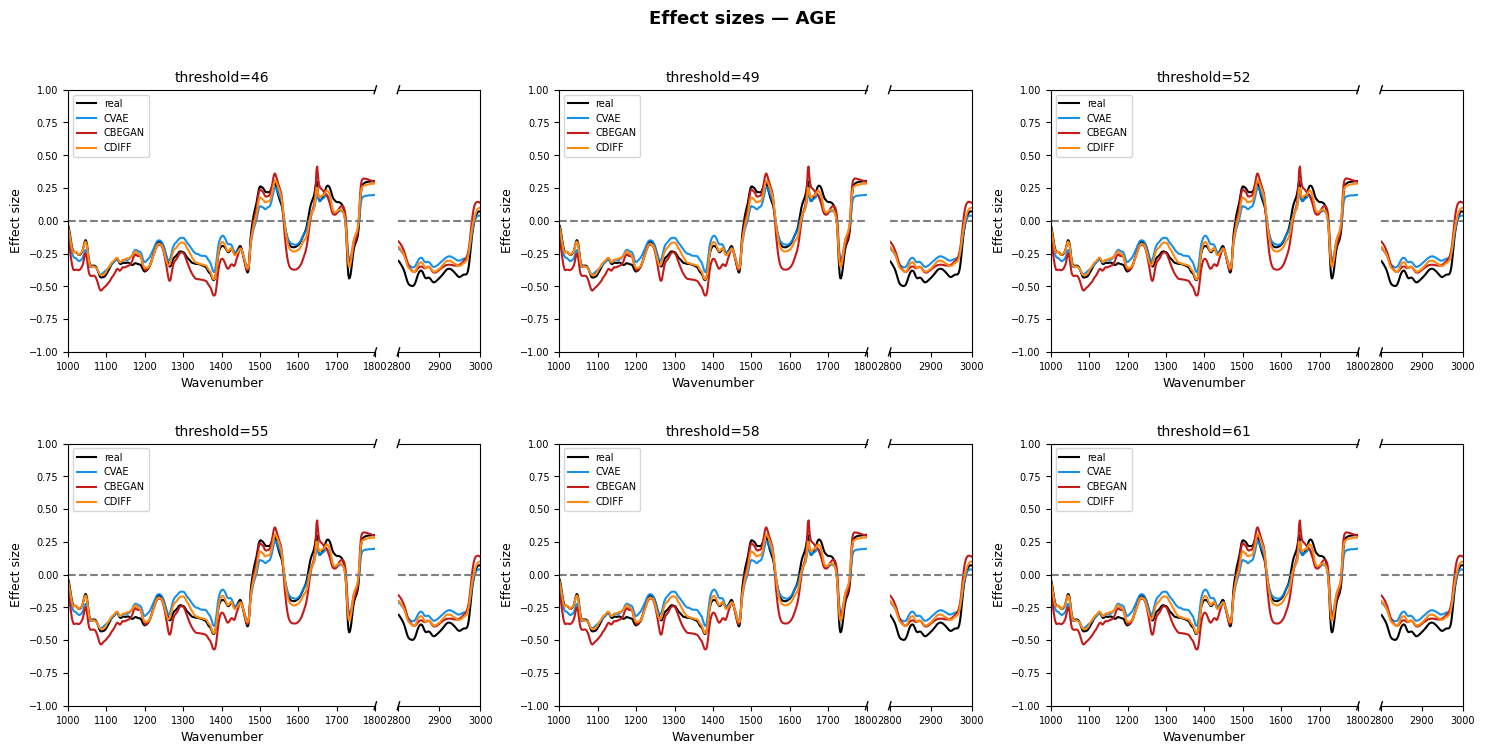

/tmp/ipykernel_20977/2030598061.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


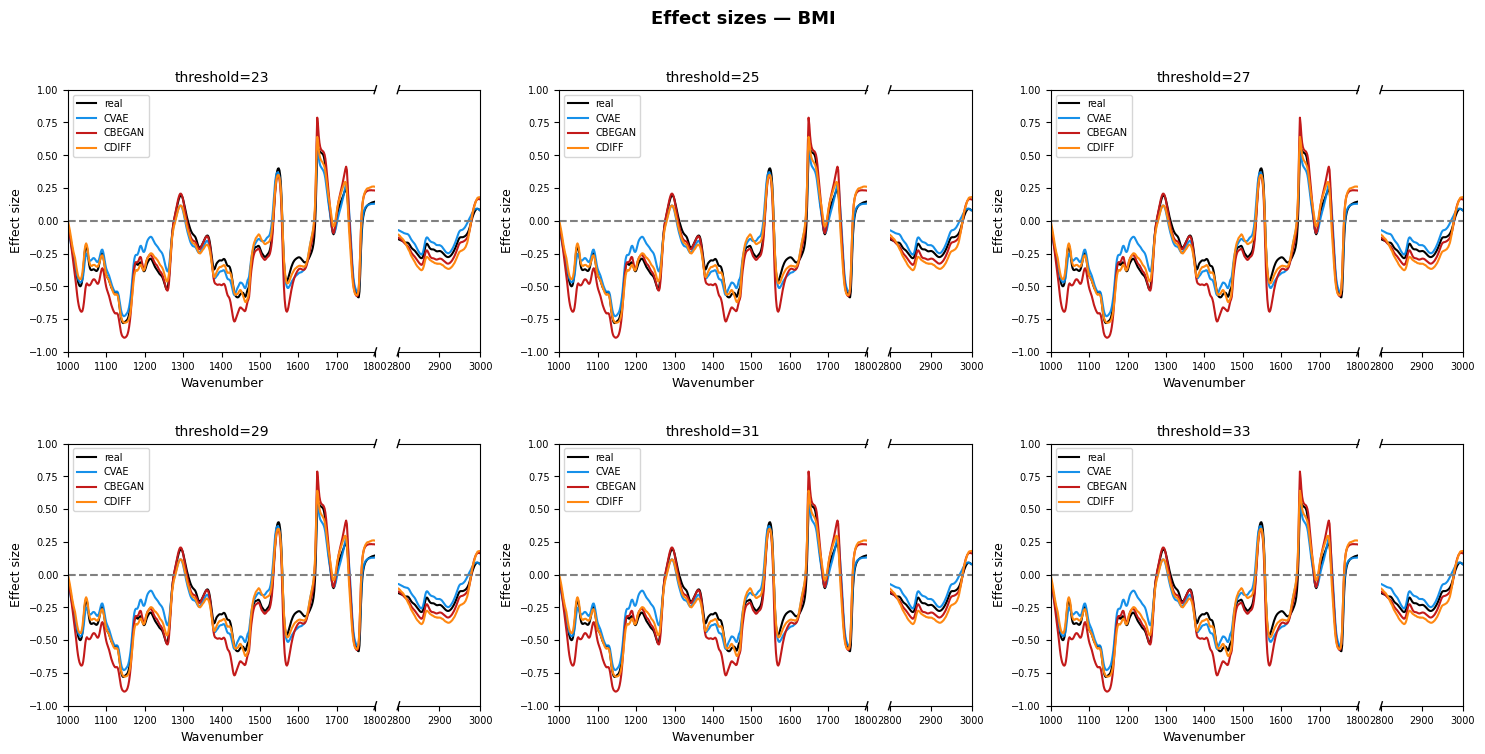

In [ ]:
stypes = ["real", "CVAE", "CBEGAN", "CDIFF"]
threshold_pairs = list(zip(age_thresholds, bmi_thresholds))
n_cols = 3
n_rows = int(np.ceil(len(threshold_pairs) / n_cols))

# Each logical subplot = 2 matplotlib axes (main + inset)
# WR pattern: [75, 20, spacer, 75, 20, spacer, 75, 20]
WR = [75, 20, 8, 75, 20, 8, 75, 20]

for label in ["age", "bmi"]:
    fig, axes = plt.subplots(
        n_rows, 8,
        figsize=(18, n_rows * 4),
        gridspec_kw={'width_ratios': WR, 'wspace': 0.15, 'hspace': 0.35}
    )
    axes = np.atleast_2d(axes)

    # hide spacer columns
    for row in range(n_rows):
        axes[row, 2].set_visible(False)
        axes[row, 5].set_visible(False)

    # logical col index → (ax_main_col, ax_inset_col)
    col_map = {0: (0, 1), 1: (3, 4), 2: (6, 7)}

    for i, (age_thr, bmi_thr) in enumerate(threshold_pairs):
        row_idx = i // n_cols
        col_idx = i % n_cols
        ax_main_col, ax_inset_col = col_map[col_idx]
        ax1 = axes[row_idx, ax_main_col]
        ax2 = axes[row_idx, ax_inset_col]

        ymins, ymaxs = [], []
        for stype in stypes:
            es = effect_size_results[(age_thr, bmi_thr)][stype][label]
            ymins.append(min(es))
            ymaxs.append(max(es))
        ylim = (min(-1, min(ymins) * 1.05), max(1, max(ymaxs) * 1.05))

        for stype in stypes:
            es = effect_size_results[(age_thr, bmi_thr)][stype][label]
            ax1.plot(vec, es, label=stype, color=colors[stype])
            ax2.plot(vec, es, color=colors[stype])

        for ax in [ax1, ax2]:
            ax.axhline(y=0, color='gray', linestyle='--')
            ax.set_ylim(*ylim)

        ax1.set_xlim(1000, 1800)
        ax2.set_xlim(2800, 3000)

        # broken axis diagonal marks
        d = 0.015
        kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
        ax1.plot((1 - d*(20/75), 1 + d*(20/75)), (-d, +d), **kwargs)
        ax1.plot((1 - d*(20/75), 1 + d*(20/75)), (1 - d, 1 + d), **kwargs)
        kwargs.update(transform=ax2.transAxes)
        ax2.plot((-d, d), (-d, +d), **kwargs)
        ax2.plot((-d, d), (1 - d, 1 + d), **kwargs)

        ax1.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax2.yaxis.set_major_locator(ticker.NullLocator())
        ax1.yaxis.tick_left()

        thr_val = age_thr if label == "age" else bmi_thr
        ax1.set_title(f"threshold={thr_val}", fontsize=10)
        ax1.set_xlabel("Wavenumber", fontsize=9)
        ax1.set_ylabel("Effect size", fontsize=9)
        ax1.legend(loc='upper left', fontsize=7)
        ax1.tick_params(labelsize=7)
        ax2.tick_params(labelsize=7)

    # hide unused subplots
    for j in range(len(threshold_pairs), n_rows * n_cols):
        row_idx = j // n_cols
        col_idx = j % n_cols
        ax_main_col, ax_inset_col = col_map[col_idx]
        axes[row_idx, ax_main_col].set_visible(False)
        axes[row_idx, ax_inset_col].set_visible(False)

    fig.suptitle(f"Effect sizes — {label.upper()}", fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f"./Sensitivity/effect_size_{label}.pdf", bbox_inches='tight')
    plt.show()

## group sizes latex table

In [15]:
def make_group_sizes_latex(labels: pd.DataFrame) -> str:
    """
    Build a LaTeX table of group sizes split by binarised age, bmi, and sex,
    shown overall and per test_set cohort.
    """
    test_sets = sorted(labels['test_set'].unique())

    # --- helper: count groups for a given slice of the dataframe -------------
    def group_counts(df):
        return {
            'N':            len(df),
            'Age high':     (df['age'] == 1).sum(),
            'Age low':      (df['age'] == 0).sum(),
            'BMI high':     (df['bmi'] == 1).sum(),
            'BMI low':      (df['bmi'] == 0).sum(),
            'Sex female':   (df['sex'] == 1).sum(),   # adjust value if encoded differently
            'Sex male':     (df['sex'] == 0).sum(),
        }

    overall = group_counts(labels)
    per_ts  = {ts: group_counts(labels[labels['test_set'] == ts]) for ts in test_sets}

    # --- build LaTeX ----------------------------------------------------------
    col_headers = ['Overall'] + [f'SVC {ts}' for ts in test_sets]
    n_data_cols = len(col_headers)
    col_spec    = 'l' + 'r' * n_data_cols

    rows = [
        r'\begin{table}[ht]',
        r'\centering',
        r'\caption{Group sizes overall and per cohort. Age and BMI are dichotomised '
        r'(high/low). All experiments are conducted within cohorts; results are '
        r'averaged across cohorts afterwards.}',
        r'\label{tab:group_sizes}',
        rf'\begin{{tabular}}{{{col_spec}}}',
        r'\toprule',
        'Group & ' + ' & '.join(col_headers) + r' \\',
        r'\midrule',
    ]

    row_labels = ['N', 'Age high', 'Age low', 'BMI high', 'BMI low', 'Sex female', 'Sex male']
    section_breaks = {'Age high': r'\addlinespace', 'BMI high': r'\addlinespace', 'Sex female': r'\addlinespace'}

    for rl in row_labels:
        if rl in section_breaks:
            rows.append(section_breaks[rl])
        vals = [str(overall[rl])] + [str(per_ts[ts][rl]) for ts in test_sets]
        rows.append(f'{rl} & ' + ' & '.join(vals) + r' \\')

    rows += [
        r'\bottomrule',
        r'\end{tabular}',
        r'\end{table}',
    ]

    return '\n'.join(rows)


latex_table = make_group_sizes_latex(labels)
print(latex_table)

\begin{table}[ht]
\centering
\caption{Group sizes overall and per cohort. Age and BMI are dichotomised (high/low). All experiments are conducted within cohorts; results are averaged across cohorts afterwards.}
\label{tab:group_sizes}
\begin{tabular}{lrrrrrrr}
\toprule
Group & Overall & SVC 1 & SVC 2 & SVC 3 & SVC 4 & SVC 5 & SVC 6 \\
\midrule
N & 5062 & 845 & 843 & 843 & 843 & 843 & 845 \\
\addlinespace
Age high & 2207 & 371 & 373 & 364 & 370 & 359 & 370 \\
Age low & 2855 & 474 & 470 & 479 & 473 & 484 & 475 \\
\addlinespace
BMI high & 2396 & 395 & 405 & 390 & 391 & 413 & 402 \\
BMI low & 2666 & 450 & 438 & 453 & 452 & 430 & 443 \\
\addlinespace
Sex female & 3398 & 571 & 560 & 572 & 563 & 561 & 571 \\
Sex male & 1664 & 274 & 283 & 271 & 280 & 282 & 274 \\
\bottomrule
\end{tabular}
\end{table}


# ICC, MMD and Frechet Distance

In [ ]:
from tools.calculation_functions import (
    within_condition_icc,
    within_condition_distribution_distance,
    compute_mmd,
    frechet_distance,
)

# ── Collect results ──────────────────────────────────────────────────────────

model_data = {'CVAE': vae_data, 'CBEGAN': gan_data, 'CDIFF': diff_data}

results = {
    'Within-Condition ICC': {
        m: within_condition_icc(d, labels[conditions])
        for m, d in model_data.items()
    } | {'higher_is_better': None},

    'Within-Condition FD': {
        m: within_condition_distribution_distance(real_data, d, labels[conditions], distance_measure='frechet')
        for m, d in model_data.items()
    } | {'higher_is_better': False},

    'Within-Condition MMD': {
        m: within_condition_distribution_distance(real_data, d, labels[conditions], distance_measure='mmd')
        for m, d in model_data.items()
    } | {'higher_is_better': False},

    'Global MMD (10 PCs)': {
        m: compute_mmd(real_data, d, n_pc_components=10)
        for m, d in model_data.items()
    } | {'higher_is_better': False},

    'Global FD': {
        m: frechet_distance(real_data, d)
        for m, d in model_data.items()
    } | {'higher_is_better': False},
}

reference_values = {
    'Within-Condition ICC': within_condition_icc(real_data, labels[conditions]),
}

# ── LaTeX table ──────────────────────────────────────────────────────────────

def get_best_model(values, higher_is_better, reference=None):
    if higher_is_better is None:
        return min(values, key=lambda m: abs(values[m] - reference))
    return (max if higher_is_better else min)(values, key=values.get)


def generate_latex_table(results, reference_values=None):
    models = ['CVAE', 'CBEGAN', 'CDIFF']
    reference_values = reference_values or {}

    rows = []
    for metric, data in results.items():
        values = {m: data[m] for m in models}
        best = get_best_model(values, data['higher_is_better'], reference_values.get(metric))
        cells = [r'\textbf{' + f'{values[m]:.4f}' + '}' if m == best else f'{values[m]:.4f}' for m in models]
        rows.append(f'{metric} & ' + ' & '.join(cells) + r' \\')

    col_spec = 'l' + 'c' * len(models)
    header = 'Metric & ' + ' & '.join(models) + r' \\'
    body = '\n'.join(rows)

    return '\n'.join([
        r'\begin{table}[h]',
        r'\centering',
        r'\caption{Comparison of Generative Models}',
        r'\label{tab:generative_models}',
        rf'\begin{{tabular}}{{{col_spec}}}',
        r'\toprule',
        header,
        r'\midrule',
        body,
        r'\bottomrule',
        r'\end{tabular}',
        r'\end{table}',
    ])


print(generate_latex_table(results, reference_values))

\begin{table}[h]
\centering
\caption{Comparison of Generative Models}
\label{tab:generative_models}
\begin{tabular}{lccc}
\toprule
Metric & VAE & GAN & Diffusion \\
\midrule
Within-Condition ICC & \textbf{0.0617} & 0.0808 & 0.0704 \\
Within-Condition FD & 24.1513 & 32.5954 & \textbf{14.4887} \\
Within-Condition MMD & 0.0070 & 0.0066 & \textbf{0.0010} \\
Global MMD (10 PCs) & 0.0035 & 0.0037 & \textbf{0.0004} \\
Global FD & 10.5337 & 22.5200 & \textbf{4.7543} \\
\bottomrule
\end{tabular}
\end{table}


In [18]:
reference_values

{'Within-Condition ICC': np.float64(0.06602481363125128)}